In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [11]:
from sklearn.datasets import load_iris

In [12]:
data=load_iris()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.DataFrame(data.target,columns=['target'])
# X

In [13]:
from sklearn.cluster import KMeans
# model
kmeans=KMeans(n_clusters=3,random_state=0,n_init="auto")
kmeans.fit(X)
kmeans.labels_
# print first 10 actual target values and predicted target values using kmeans
print(y["target"].head(10))
print(kmeans.labels_[:10])

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64
[1 1 1 1 1 1 1 1 1 1]


In [14]:
print(kmeans.cluster_centers_)

[[5.88360656 2.74098361 4.38852459 1.43442623]
 [5.006      3.428      1.462      0.246     ]
 [6.85384615 3.07692308 5.71538462 2.05384615]]


In [15]:
# define last column in dataset as clusters with predicted cluster value
X["clusters"]=kmeans.labels_
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   clusters  
0         1  
1         1  
2         1  
3         1  
4         1  


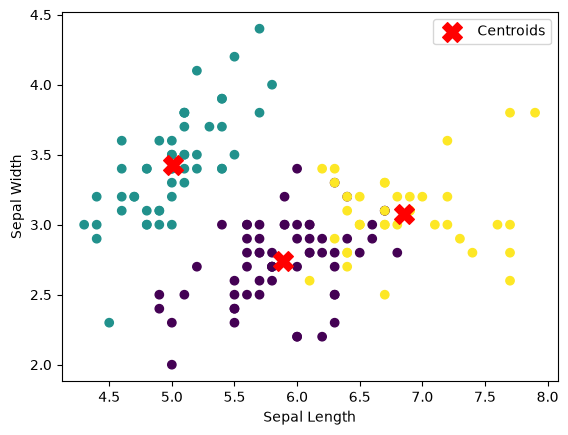

In [16]:
import matplotlib.pyplot as plt
# visualize clusters with there centeroid
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import silhouette_score
# silhouette score foe evaluating cluster
score = silhouette_score(X.iloc[:,:-1], kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.5511916046195927


In [18]:
# check silhouette score for different k vallues
for i in range(2,6):
   kmeans=KMeans(n_clusters=i,random_state=0,n_init="auto")
   kmeans.fit(X)
   score = silhouette_score(X.iloc[:,:-1], kmeans.labels_)
   print("Silhouette Score for",i,"clusters is:", score)

Silhouette Score for 2 clusters is: 0.6810461692117465
Silhouette Score for 3 clusters is: 0.5511916046195927
Silhouette Score for 4 clusters is: 0.479998508909311
Silhouette Score for 5 clusters is: 0.47771293608661863
